#Air Quality Prediction Using Machine Learning
## Project Overview
This notebook builds a **time-series forecasting model** to predict air pollution levels  
across major Indian cities using the Prophet library and classical ML evaluation metrics.

**Dataset:** air_quality_dataset.csv  
**Target Variable:** AQI  
## Notebook Structure


1.   Understanding the Dataset
2.   Data Preprocessing
3. Visualisations
4. Prepare Dataset
5. Prophet Model and Forecasting
6. Model Evaluation Metrics
7. Actual VS Predicted Data
8. 7-Day Forecast



##Understanding the Dataset

In [57]:
#Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
from google.colab import files
uploaded = files.upload()

Saving air_pollution_data.csv to air_pollution_data (2).csv


In [84]:
#Load and Understand the dataset
data = pd.read_csv('air_pollution_data.csv')
df = pd.DataFrame(data)

In [85]:
#Shows First 5 values to understand the structure
df.head()

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,30-11-2020,5,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36
1,Ahmedabad,01-12-2020,5,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36
2,Ahmedabad,02-12-2020,5,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12
3,Ahmedabad,03-12-2020,5,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48
4,Ahmedabad,04-12-2020,5,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53


In [86]:
#Shows null values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23504 entries, 0 to 23503
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    23504 non-null  object 
 1   date    23504 non-null  object 
 2   aqi     23504 non-null  int64  
 3   co      23504 non-null  float64
 4   no      23504 non-null  float64
 5   no2     23504 non-null  float64
 6   o3      23504 non-null  float64
 7   so2     23504 non-null  float64
 8   pm2_5   23504 non-null  float64
 9   pm10    23504 non-null  float64
 10  nh3     23504 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 2.0+ MB


In [87]:
print("Null Values: ")
print(df.isnull().sum().sum())

Null Values: 
0


In [88]:
print("Descriptive Statistics: ") #Shows Statistical Summary (mean, std, quartiles)
df.describe()

Descriptive Statistics: 


,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,23504.000000,23504.000000,23504.00000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000,23504.000000
mean,3.920354,1113.224543,6.00554,25.044104,35.059777,15.971449,98.598310,121.848091,12.060212
std,1.415490,1401.770372,24.50272,25.839242,31.901760,23.943464,135.572391,160.429589,17.544759
min,1.000000,173.570000,0.00000,0.310000,0.000000,0.190000,0.500000,0.580000,0.000000
25%,3.000000,447.270000,0.00000,8.740000,7.870000,4.470000,24.677500,32.277500,2.340000
50%,5.000000,700.950000,0.00000,16.450000,28.250000,7.990000,58.860000,75.775000,6.520000
75%,5.000000,1188.280000,0.27000,32.220000,54.360000,16.450000,117.605000,147.642500,15.830000
max,5.000000,23071.290000,457.76000,331.760000,406.270000,442.510000,2203.550000,2429.130000,352.620000





*   There are no missing values in the dataset
*   Attributes include: 'city','date','aqi', and other pollutants

*   Range is very wide, might require scaling








##Data Preprocessing

In [89]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')

In [90]:
print("\nUnique cities:", df['city'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())


Unique cities: 26
Date range: 2020-11-30 00:00:00 to 2023-05-25 00:00:00


In [91]:
# Check for any -200 values, although, minimum values do not include '-200'
if (df == -200).any().any():
    df = df.replace(-200, np.nan)
    print("Found")
else:
    print("Not Found")

Not Found


*   Minimum values do not include '-200'

##Visualisations

10 Most Polluted Cities: 
city
Delhi           4.808628
Jorapokhar      4.806416
Amritsar        4.782080
Patna           4.756637
Lucknow         4.698009
Gurugram        4.682522
Kolkata         4.613938
Chandigarh      4.358407
Jaipur          4.336283
Brajrajnagar    4.284292
Name: aqi, dtype: float64


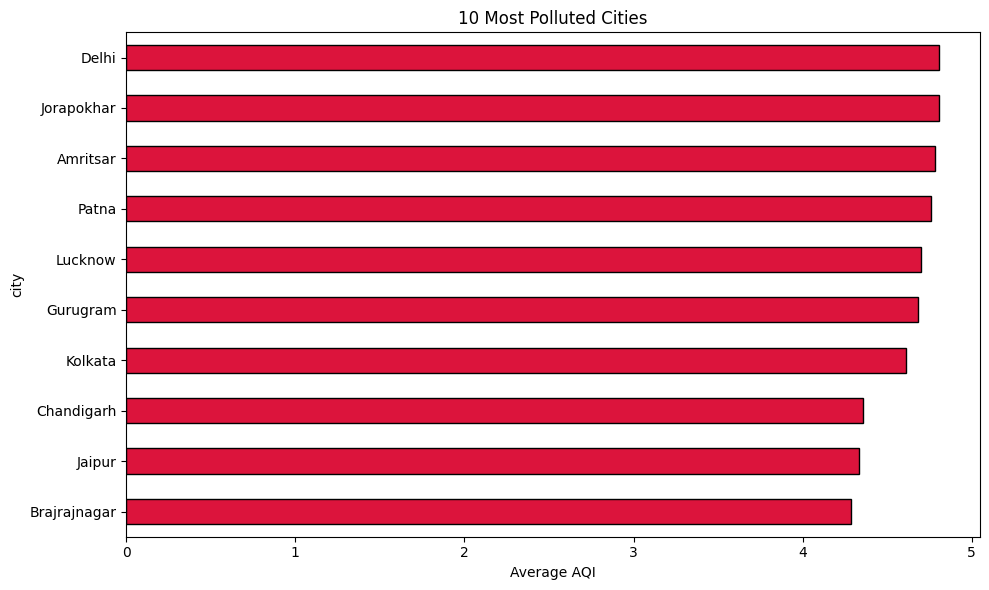

In [92]:
#Top 10 Most Polluted Cities (by average AQI)

city_avg_aqi = df.groupby('city')['aqi'].mean().sort_values(ascending=False)

_cities = city_avg_aqi.head(10)
print("10 Most Polluted Cities: ")
print(_cities)

#Horizontal bar plot
plt.figure(figsize=(10,6))
_cities.plot(kind='barh', color='crimson', edgecolor='black')
plt.xlabel('Average AQI')
plt.title('10 Most Polluted Cities')
plt.gca().invert_yaxis()  #highest at top
plt.tight_layout()
plt.show()


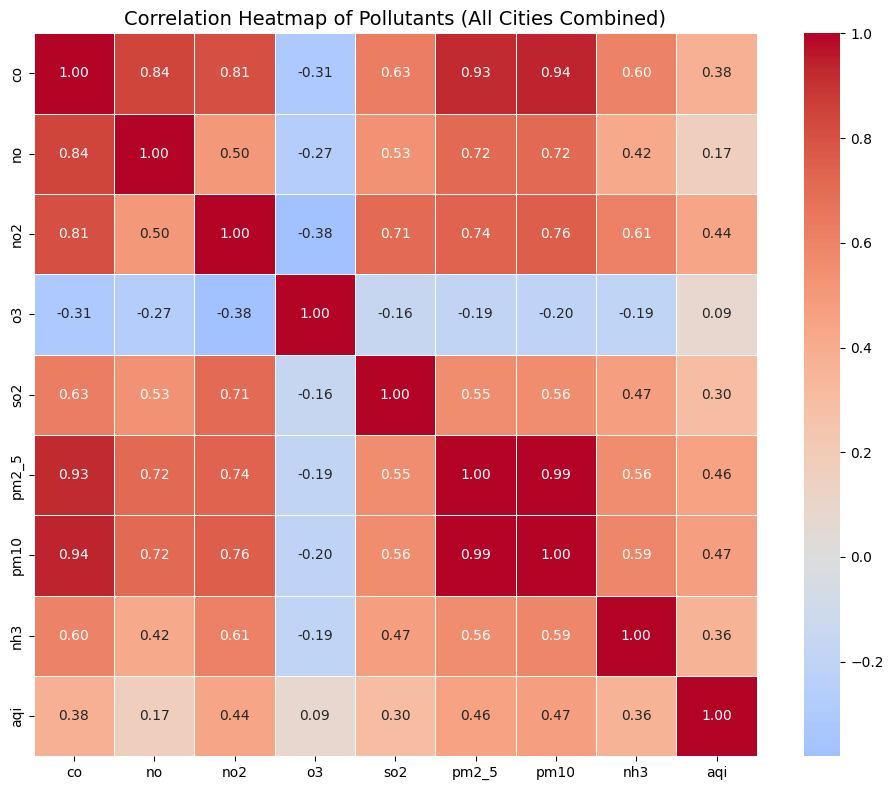

In [93]:
#Correlation Heatmap

pollutant_cols = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3', 'aqi']

#Compute correlation matrix
corr_matrix_all = df[pollutant_cols].corr()

#Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_all,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            fmt='.2f')
plt.title('Correlation Heatmap of Pollutants (All Cities Combined)', fontsize=14)
plt.tight_layout()
plt.show()


*   'aqi' is dependent on 'pm10','pm2_5','no2','co' the most
*   'o3' has the lowest explanatory power over 'aqi' than the other pollutants




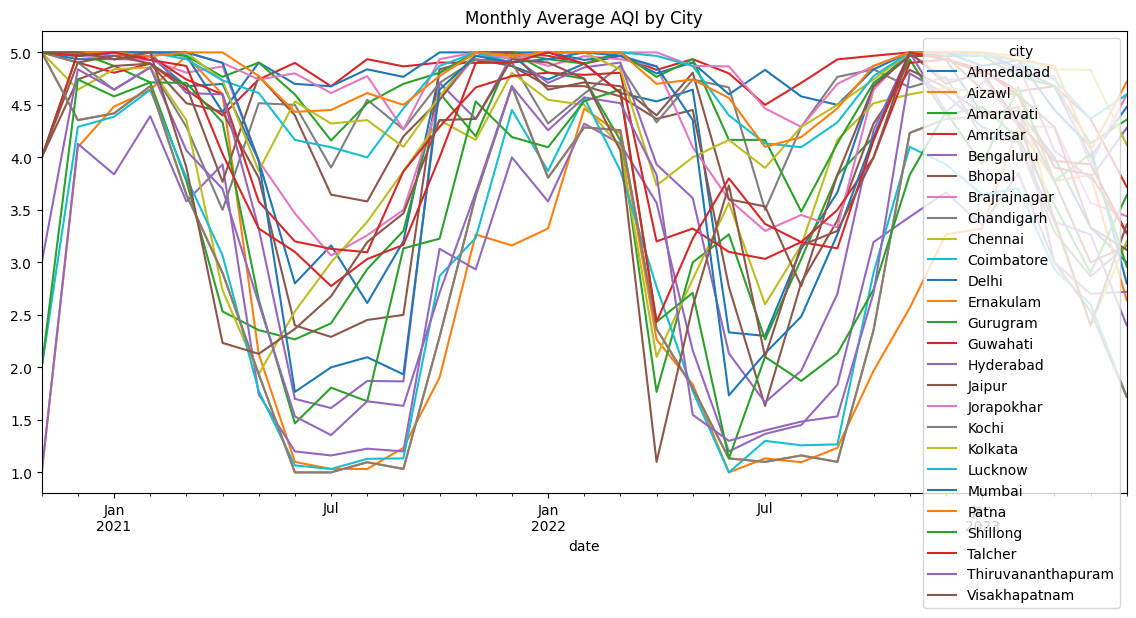

In [94]:
#Average AQI per month per city
monthly_avg = df.groupby([df['city'], df['date'].dt.to_period('M')])['aqi'].mean().unstack(0) #unstack(0) pivots the first attribute 'city' to create a legend seperate from the graph
monthly_avg.plot(figsize=(14,6))
plt.title('Monthly Average AQI by City')
plt.show()

##Prepare data for the Prophet model

In [95]:
#Sort by city and date for consistency
df = df.sort_values(['city', 'date']).reset_index(drop=True)

In [96]:
df

,city,date,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Ahmedabad,2020-11-30,5,520.71,2.38,16.28,130.18,47.68,65.96,72.13,8.36
1,Ahmedabad,2020-12-01,5,1682.28,7.71,54.84,0.73,21.70,120.95,154.53,27.36
2,Ahmedabad,2020-12-02,5,1815.80,16.54,49.35,0.17,23.84,133.47,172.63,28.12
3,Ahmedabad,2020-12-03,5,2296.45,41.57,40.10,0.00,35.76,150.37,202.15,36.48
4,Ahmedabad,2020-12-04,5,2189.64,23.92,58.95,0.02,28.13,160.79,205.80,40.53
...,...,...,...,...,...,...,...,...,...,...,...
23499,Visakhapatnam,2023-05-21,3,353.81,0.00,2.08,100.14,4.11,37.53,47.09,0.08
23500,Visakhapatnam,2023-05-22,3,380.52,0.00,3.77,82.97,5.07,32.17,43.44,1.74
23501,Visakhapatnam,2023-05-23,3,390.53,0.00,4.28,80.11,5.19,36.01,48.06,1.20
23502,Visakhapatnam,2023-05-24,3,300.41,0.00,1.36,95.84,2.21,30.17,48.89,0.00


In [97]:
#Keep only date, AQI and top 4 regressors with the highest correlation from the correlation heatmap
df1=df[df['city']=='Ahmedabad'].copy()
df1 = df1[['date', 'aqi', 'pm10', 'pm2_5', 'no2', 'co', 'nh3']]

In [98]:
#verify the number of records
df1

,date,aqi,pm10,pm2_5,no2,co,nh3
0,2020-11-30,5,72.13,65.96,16.28,520.71,8.36
1,2020-12-01,5,154.53,120.95,54.84,1682.28,27.36
2,2020-12-02,5,172.63,133.47,49.35,1815.80,28.12
3,2020-12-03,5,202.15,150.37,40.10,2296.45,36.48
4,2020-12-04,5,205.80,160.79,58.95,2189.64,40.53
...,...,...,...,...,...,...,...
899,2023-05-21,3,53.68,18.87,10.28,350.48,6.71
900,2023-05-22,3,65.63,16.86,7.97,313.76,4.88
901,2023-05-23,3,68.64,18.04,12.34,390.53,6.46
902,2023-05-24,3,73.56,18.49,8.74,307.08,3.86


In [99]:
#Rename columns as Phophet requires attributes (Independent variable: ds, Dependent Variable: y) to be named accordingly
model_df = df1.rename(columns={'date': 'ds', 'aqi': 'y'})
model_df['ds'] = pd.to_datetime(model_df['ds'], dayfirst=True) #Maintain datetime datatype
model_df = model_df.sort_values('ds').reset_index(drop=True)

In [100]:
model_df

,ds,y,pm10,pm2_5,no2,co,nh3
0,2020-11-30,5,72.13,65.96,16.28,520.71,8.36
1,2020-12-01,5,154.53,120.95,54.84,1682.28,27.36
2,2020-12-02,5,172.63,133.47,49.35,1815.80,28.12
3,2020-12-03,5,202.15,150.37,40.10,2296.45,36.48
4,2020-12-04,5,205.80,160.79,58.95,2189.64,40.53
...,...,...,...,...,...,...,...
899,2023-05-21,3,53.68,18.87,10.28,350.48,6.71
900,2023-05-22,3,65.63,16.86,7.97,313.76,4.88
901,2023-05-23,3,68.64,18.04,12.34,390.53,6.46
902,2023-05-24,3,73.56,18.49,8.74,307.08,3.86


In [101]:
#Add bounds for logistic growth
model_df['cap'] = 5
model_df['floor'] = 1

In [102]:
#Splitting train and test data, last 30 days for testing
train = model_df.iloc[:-30]
test = model_df.iloc[-30:]

##Prophet Model Training and Forecasting

In [103]:
from prophet import Prophet

model = Prophet(
    growth='logistic', #Trend will never exceed the range
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.3
)


for col in ['pm10', 'pm2_5', 'no2', 'co', 'nh3']:
    model.add_regressor(col) #These regressors have the highest correlation with AQI, using just the date would prevent the model from capturing patterns

model.fit(train)

# Use test directly
future = test[['ds', 'pm10', 'pm2_5', 'no2', 'co', 'nh3', 'cap', 'floor']].copy()
forecast = model.predict(future)

predicted = forecast['yhat'].values

##Model Evaluation Metrics

In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#Calculate metrics
mae = mean_absolute_error(test['y'], predicted)
rmse = np.sqrt(mean_squared_error(test['y'], predicted))
r2 = r2_score(test['y'], predicted)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

MAE: 0.77
RMSE: 0.92
R²: 0.06




*   Average Prediction Error (Mean Absolute Error) suggests that the predicted value is off by around 0.81


*   The RMSE suggests that the model gives higher weightage to large errors
*   The model has a very low R^2 value of 6%, only 6% of variation in AQI is explained by the predictors


*   This suggests that model is not that suitable for prediction


*   This may be improved by creating regressors or using a larger dataset









##Visualising Actual data VS Predicted data

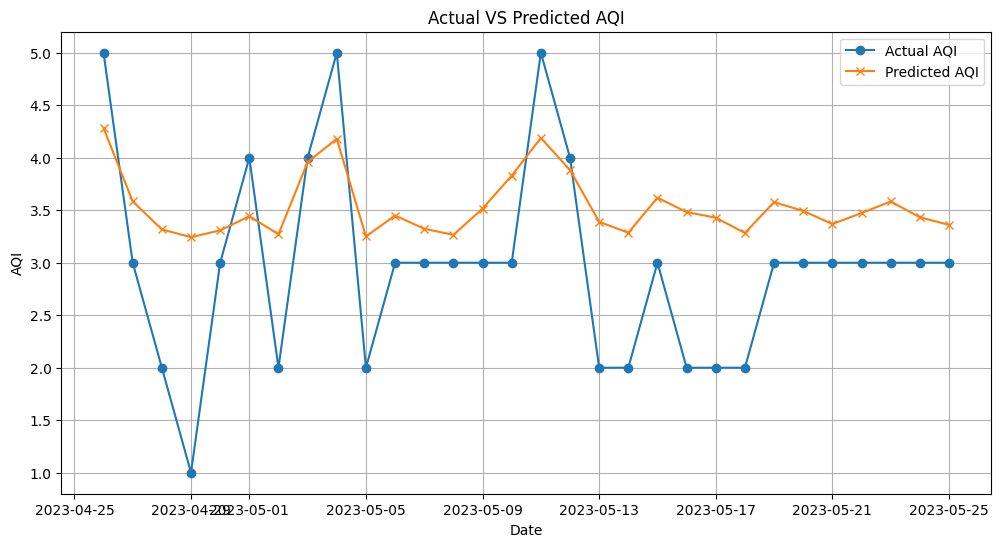

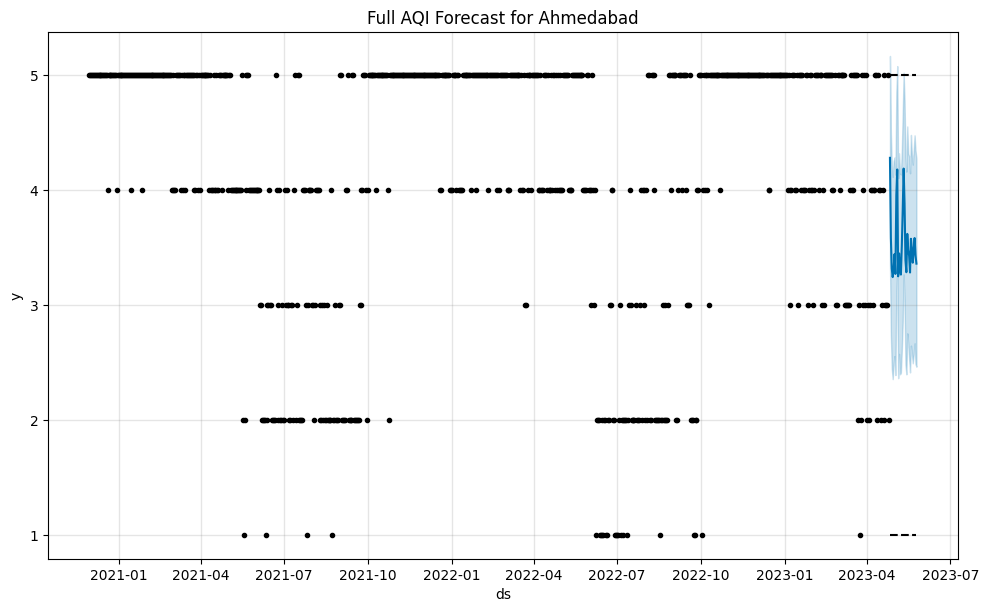

In [105]:
plt.figure(figsize=(12,6))
plt.plot(test['ds'], test['y'], label='Actual AQI', marker='o')
plt.plot(test['ds'], predicted, label='Predicted AQI', marker='x')
plt.title(f'Actual VS Predicted AQI')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

#full forecast plot
fig = model.plot(forecast)
plt.title(f'Full AQI Forecast for Ahmedabad')
plt.show()

##7-Day Forecast:

Prophet 7-day forecast:
             ds      yhat  yhat_lower  yhat_upper
874 2023-04-26  3.696281    2.804276    4.549289
875 2023-04-27  3.715306    2.859119    4.608273
876 2023-04-28  3.701455    2.836820    4.605448
877 2023-04-29  3.716611    2.864495    4.605977
878 2023-04-30  3.663126    2.803905    4.565845
879 2023-05-01  3.654495    2.848936    4.595101
880 2023-05-02  3.740140    2.843127    4.644259


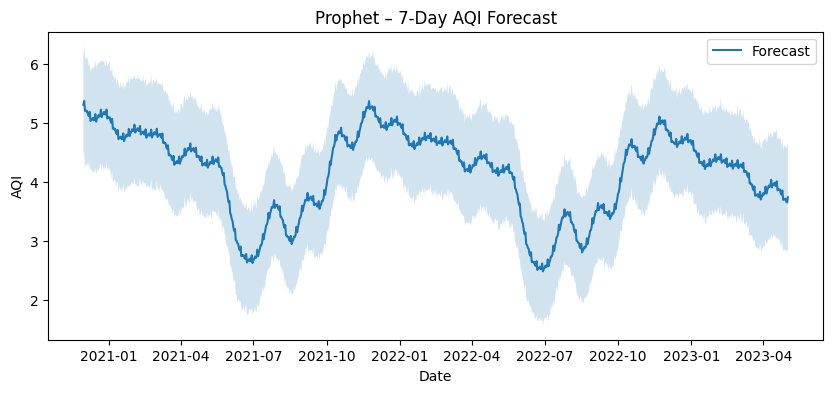

In [107]:
#Forecast 7 days into the future
future_week = model.make_future_dataframe(periods=7)
future_week['cap'] = 5
future_week['floor'] = 1

for col in ['pm10', 'pm2_5', 'no2', 'co', 'nh3']:
    future_week[col] = train[col].tail(30).mean()
forecast_week = model.predict(future_week)

one_week_forecast = forecast_week[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)
print("Prophet 7-day forecast:\n", one_week_forecast)

#Plot
plt.figure(figsize=(10,4))
plt.plot(forecast_week['ds'], forecast_week['yhat'], label='Forecast')
plt.fill_between(forecast_week['ds'],
                 forecast_week['yhat_lower'],
                 forecast_week['yhat_upper'], alpha=0.2)
plt.title('Prophet – 7‑Day AQI Forecast')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()